In [ ]:
import pandas as pd



In [2]:
df = pd.read_csv('/content/Salary_Data.csv')

In [3]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [4]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [6]:
for column in ['Age', 'Years of Experience', 'Salary']:
    if column in df.columns:
        df[column].fillna(df[column].mean(), inplace=True)

for column in ['Gender', 'Education Level', 'Job Title']:
    if column in df.columns:
        # Mode might return multiple values if there's a tie, so take the first one.
        df[column].fillna(df[column].mode()[0], inplace=True)

# Verify that null values have been handled
df.isnull().sum()

/tmp/ipykernel_11126/941161409.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [9]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f"Number of duplicate rows removed: {initial_rows - final_rows}")
print(f"DataFrame shape after removing duplicates: {df.shape}")

Number of duplicate rows removed: 0
DataFrame shape after removing duplicates: (1792, 6)


In [8]:
from sklearn.preprocessing import LabelEncoder


In [10]:
# Separate input features (X) and output variable (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

print("Input Features (X):")
display(X.head())

print("\nOutput Variable (y):")
display(y.head())

Input Features (X):


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,Male,Bachelor's,Software Engineer,5.0
1,28.0,Female,Master's,Data Analyst,3.0
2,45.0,Male,PhD,Senior Manager,15.0
3,36.0,Female,Bachelor's,Sales Associate,7.0
4,52.0,Male,Master's,Director,20.0



Output Variable (y):


,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1433, 5)
X_test shape: (359, 5)
y_train shape: (1433,)
y_test shape: (359,)


### Encoding Categorical Features

Before training the models, we need to convert the categorical features ('Gender', 'Education Level', 'Job Title') into numerical representations using `LabelEncoder`. This is applied to both the training and testing sets to ensure consistency.

In [18]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# List of categorical columns to encode
categorical_cols = ['Gender', 'Education Level', 'Job Title']

# Apply LabelEncoder to each categorical column in both X_train and X_test
for col in categorical_cols:
    le = LabelEncoder()
    # Fit the encoder on the combined unique string values from both train and test sets
    # to ensure all possible labels are learned.
    full_data_col = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le.fit(full_data_col)

    # Transform both train and test data, ensuring they are string type
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

print("X_train after encoding:")
display(X_train.head())
print("\nX_test after encoding:")
display(X_test.head())

X_train after encoding:


,Age,Gender,Education Level,Job Title,Years of Experience
3391,36.0,1,1,87,10.0
6460,29.0,1,1,12,5.0
6470,23.0,1,1,12,1.0
6385,36.0,1,1,10,6.0
175,35.0,1,0,47,7.0



X_test after encoding:


,Age,Gender,Education Level,Job Title,Years of Experience
1776,29.0,1,1,198,5.0
221,31.0,0,0,216,3.0
3102,33.0,1,1,198,9.0
1101,27.0,1,0,257,5.0
5251,29.0,0,5,187,5.0


### 1. Linear Regression Model

We'll start by building a simple Linear Regression model to establish a baseline for performance.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance:")
print(f"  Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"  Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"  R-squared (R2): {r2_linear:.2f}")

Linear Regression Performance:
  Mean Absolute Error (MAE): 20468.78
  Mean Squared Error (MSE): 777578633.91
  R-squared (R2): 0.69


### 2. K-Nearest Neighbors (KNN) Regressor

Next, let's build a KNN Regressor, which is a non-parametric method used for classification and regression.

In [20]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize the KNN Regressor (e.g., with n_neighbors=5)
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"  Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"  R-squared (R2): {r2_knn:.2f}")

K-Nearest Neighbors Regressor Performance:
  Mean Absolute Error (MAE): 32014.14
  Mean Squared Error (MSE): 1447213459.32
  R-squared (R2): 0.42


### 3. Support Vector Machine (SVM) Regressor

Now, we'll implement a Support Vector Regressor (SVR).

In [21]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVMs are sensitive to feature scaling, so we'll scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVR model
svr_model = SVR(kernel='rbf') # Radial Basis Function kernel is common

# Train the model
svr_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate the model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor (SVR) Performance:")
print(f"  Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"  Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"  R-squared (R2): {r2_svr:.2f}")

Support Vector Regressor (SVR) Performance:
  Mean Absolute Error (MAE): 42929.14
  Mean Squared Error (MSE): 2506432341.95
  R-squared (R2): -0.01


### 4. Decision Tree Regressor

Let's build a Decision Tree Regressor, a simple yet powerful tree-based model.

In [22]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"  Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"  R-squared (R2): {r2_dt:.2f}")

Decision Tree Regressor Performance:
  Mean Absolute Error (MAE): 28650.89
  Mean Squared Error (MSE): 1472116579.31
  R-squared (R2): 0.41


### 5. Random Forest Regressor

Finally, we'll build a Random Forest Regressor, an ensemble method that generally provides better performance than a single decision tree.

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # 100 trees is a common default

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Performance:
  Mean Absolute Error (MAE): 24353.27
  Mean Squared Error (MSE): 880808856.78
  R-squared (R2): 0.65


### 6. Model Comparison Visualizations

Let's visually compare the performance of all trained models based on their Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared values.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame to store the evaluation results
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regressor', 'SVR', 'Decision Tree', 'Random Forest'],
    'MAE': [mae_linear, mae_knn, mae_svr, mae_dt, mae_rf],
    'MSE': [mse_linear, mse_knn, mse_svr, mse_dt, mse_rf],
    'R2': [r2_linear, r2_knn, r2_svr, r2_dt, r2_rf]
})

display(results_df.set_index('Model'))

,MAE,MSE,R2
Model,,,
Linear Regression,20468.780857,7.775786e+08,0.687619
KNN Regressor,32014.142159,1.447213e+09,0.418603
SVR,42929.139543,2.506432e+09,-0.006923
Decision Tree,28650.885231,1.472117e+09,0.408598
Random Forest,24353.273774,8.808089e+08,0.646148


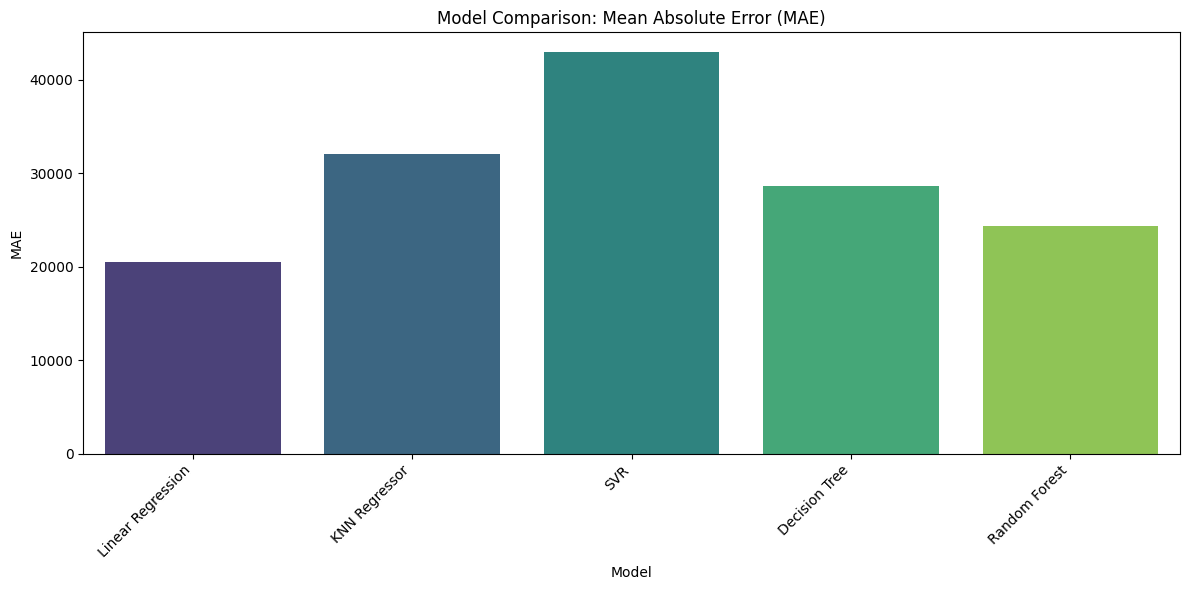

In [28]:
# Plotting MAE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MAE', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Comparison: Mean Absolute Error (MAE)')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

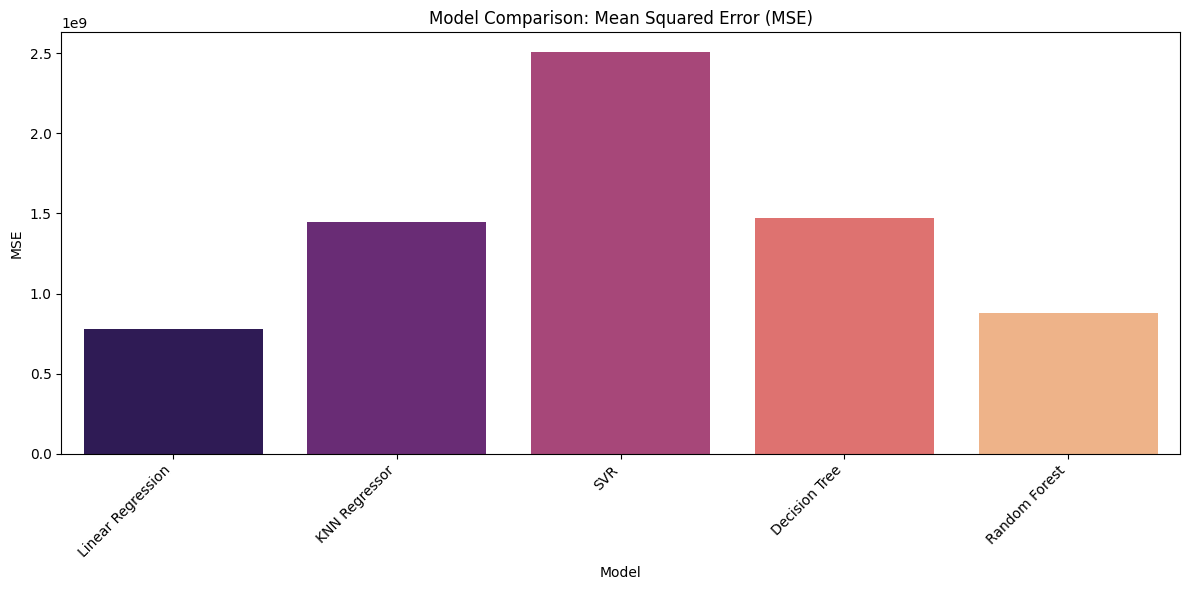

In [29]:
# Plotting MSE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MSE', data=results_df, palette='magma', hue='Model', legend=False)
plt.title('Model Comparison: Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

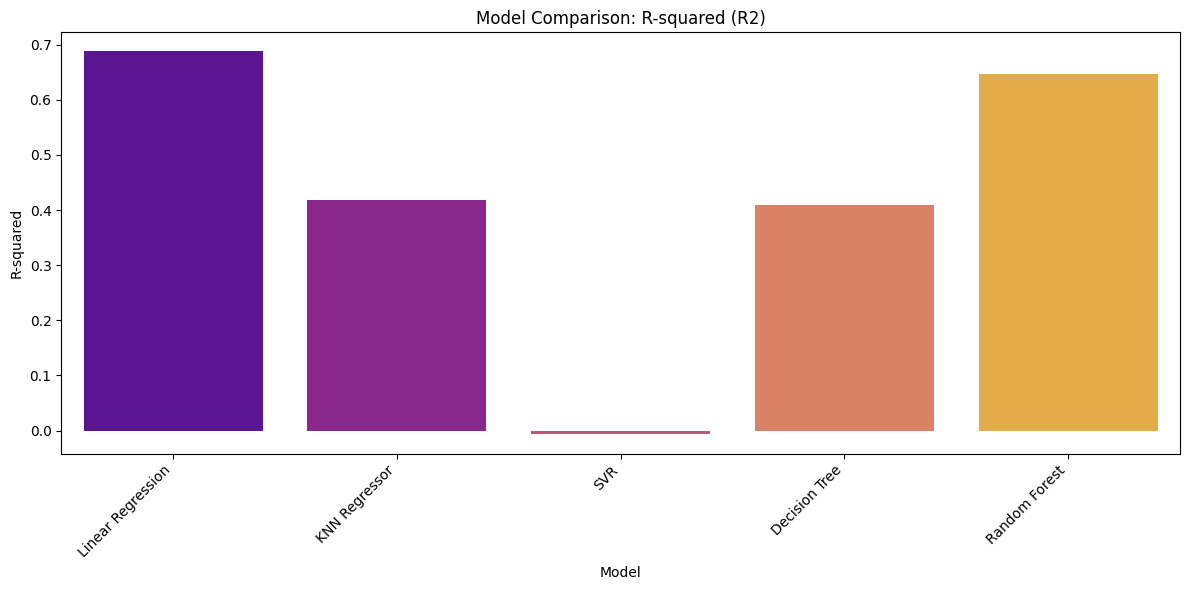

In [30]:
# Plotting R-squared
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2', data=results_df, palette='plasma', hue='Model', legend=False)
plt.title('Model Comparison: R-squared (R2)')
plt.ylabel('R-squared')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7. Save the Best Model

Based on the evaluation metrics, the Linear Regression model performed the best. We will now save this model using the `pickle` library for future use.

In [31]:
import pickle

# Define the filename for the saved model
model_filename = 'linear_regression_model.pkl'

# Save the best model (linear_model) to a .pkl file
with open(model_filename, 'wb') as file:
    pickle.dump(linear_model, file)

print(f"Linear Regression model saved successfully to '{model_filename}'")

Linear Regression model saved successfully to 'linear_regression_model.pkl'
